# 🚀 VoltVision — Advanced Feature Engineering + Model Training

Notebook 04 gave us something much more useful than another leaderboard score: **evidence about where the current system is weak**.

This notebook uses that evidence to build the next model deliberately. We are not going to create dozens of random features or blindly increase tree depth.

The progression is:

**Notebook-04 evidence → cleaner representation → targeted feature groups → CV selection → native categorical CatBoost → controlled tuning → 5-fold OOF → probability/rank ensemble → weak-group check → Kaggle submissions**

🎯 **Primary metric:** ROC-AUC

The score to beat is the OOF system from Notebook 04. Every feature group has to earn its place through cross-validation.

## Imports and Configuration

In [1]:
import json
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42

In [2]:
# Full competition run
FAST_MODE = False

# Expensive branches
RUN_TUNING = True
RUN_XGB_TUNING = False

# Final CV
N_SPLITS = 5

# Controlled tuning budget
N_TRIALS_LGB = 30
N_TRIALS_CAT = 25
N_TRIALS_XGB = 15

# Fast smoke mode automatically reduces these values.
if FAST_MODE:
    N_SPLITS = 2
    N_TRIALS_LGB = 2
    N_TRIALS_CAT = 2
    N_TRIALS_XGB = 2

print("FAST_MODE:", FAST_MODE)
print("Final CV folds:", N_SPLITS)
print("Tuning:", RUN_TUNING)

FAST_MODE: False
Final CV folds: 5
Tuning: True


`FAST_MODE=False` is the real project run. The fast branch exists only so the notebook can be tested end-to-end without waiting for the full competition workload.

## Load Raw Data and Notebook-04 Evidence

In [3]:
BASE = Path("..")
DATA_PATH = BASE / "data"
ANALYSIS_PATH = BASE / "analysis"
SUBMISSION_PATH = BASE / "submissions"
MODELS_PATH = BASE / "models"

ANALYSIS_PATH.mkdir(parents=True, exist_ok=True)
SUBMISSION_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

train_raw = pd.read_csv(DATA_PATH / "train.csv")
test_raw = pd.read_csv(DATA_PATH / "test.csv")

problem_path = ANALYSIS_PATH / "model_problem_summary.csv"
oof_path = ANALYSIS_PATH / "oof_predictions.csv"
feature_diag_path = ANALYSIS_PATH / "feature_diagnostics.csv"

problem_summary = pd.read_csv(problem_path) if problem_path.exists() else pd.DataFrame()
old_oof = pd.read_csv(oof_path) if oof_path.exists() else pd.DataFrame()
feature_diagnostics = pd.read_csv(feature_diag_path) if feature_diag_path.exists() else pd.DataFrame()

print("Raw train:", train_raw.shape)
print("Raw test :", test_raw.shape)
print("Problem summary loaded:", not problem_summary.empty)
print("OOF evidence loaded:", not old_oof.empty)
print("Feature diagnostics loaded:", not feature_diagnostics.empty)

Raw train: (668665, 15)
Raw test : (286571, 14)
Problem summary loaded: True
OOF evidence loaded: True
Feature diagnostics loaded: True


In [4]:
problem_summary

,Problem,Evidence,Severity,Likely_Fix
0,Weak customer subgroups,Overall-to-worst subgroup AUC gap = 0.116575,HIGH,Create evidence-based interactions for the wea...
1,Feature/model plateau,Last learning-curve validation gain = 0.000088,HIGH,"If plateaued, prioritize better interactions/r..."
2,Low ensemble diversity,Mean OOF rank correlation = 0.994406,MEDIUM,Add genuinely different representations/models...
3,Generalization gap / overfitting,Train-valid AUC gap = 0.004532,LOW,"Regularize tree complexity, verify early stopp..."
4,Fold instability,LightGBM fold AUC std = 0.000814,LOW,"Use stronger CV, seed averaging, and avoid fea..."
5,Calibration distortion,ECE = 0.000645; Brier = 0.070824,LOW,Useful for probability quality; lower priority...
6,Train/test distribution shift,Adversarial AUC = 0.499996; max PSI = 0.0001,LOW,"Downweight drift-heavy features, use robust va..."
7,Seed sensitivity,Seed AUC std = 0.000048,LOW,Use seed averaging if instability is meaningful.
8,Noisy / redundant engineered features,Best AUC change after removing a feature group...,LOW,Remove or redesign feature groups whose remova...
9,Holdout blend-weight overfitting,Holdout gain - OOF gain = -0.000010,LOW,"Choose blend weights from OOF predictions, the..."


The model-problem notebook is our design document now. High-severity findings should influence the next representation; low-severity findings should not distract us.

## Evidence from Notebook 04

In [5]:
reference_auc = np.nan
reference_name = None

if not old_oof.empty and {"target", "OOF_Blend"}.issubset(old_oof.columns):
    reference_auc = roc_auc_score(old_oof["target"], old_oof["OOF_Blend"])
    reference_name = "Notebook 04 OOF Blend"

print("Reference system:", reference_name)
print("Reference OOF AUC:", round(float(reference_auc), 6) if pd.notna(reference_auc) else "not available")
print("OOF rows available:", len(old_oof))

Reference system: Notebook 04 OOF Blend
Reference OOF AUC: 0.942359
OOF rows available: 668665


In [6]:
if not feature_diagnostics.empty:
    cols = [c for c in ["Feature", "Permutation_Mean", "SHAP_MeanAbs", "Max_Abs_Spearman_With_Other_Feature"] if c in feature_diagnostics.columns]
    display(feature_diagnostics[cols].sort_values(cols[1] if len(cols) > 1 else cols[0], ascending=False).head(15))

,Feature,Permutation_Mean,SHAP_MeanAbs,Max_Abs_Spearman_With_Other_Feature
13,Subsidy_x_Concern,0.092218,NaN,0.864210
16,Income_x_Concern,0.033372,NaN,0.837795
1,Annual_Income_USD,0.016528,NaN,0.626344
6,Environmental_Concern_Level,0.006792,NaN,0.837795
17,Subsidy_x_Income,0.004661,NaN,0.859683
9,Range_Anxiety_Level,0.003702,NaN,0.999830
2,Daily_Commute_km,0.002053,NaN,0.180234
14,Subsidy_x_LowAnxiety,0.001984,NaN,0.886828
11,Income_Per_Car,0.001070,NaN,0.738990
0,Age,0.000638,NaN,0.008702


Notebook 04 showed that the current model is already strong globally, so the next gains are more likely to come from **within-segment ranking** and **better representation** than from simply adding trees.

The feature diagnostics also warned us about redundancy: some old engineered columns were almost duplicates of raw variables. This notebook therefore starts again from raw train/test and only keeps advanced features that survive CV.

## Prepare the Working Dataset

In [7]:
target_map = {"No": 0, "Yes": 1}
y_full = train_raw["Will_Buy_EV"].map(target_map).astype(int)
train_ids_full = train_raw["id"].copy()
test_ids_full = test_raw["id"].copy()

if FAST_MODE:
    # Stratified sample for end-to-end notebook testing.
    tmp = pd.DataFrame({"idx": np.arange(len(train_raw)), "y": y_full})
    fast_idx, _ = train_test_split(
        tmp["idx"],
        train_size=min(8000, len(train_raw)),
        stratify=tmp["y"],
        random_state=RANDOM_STATE
    )
    fast_idx = np.sort(fast_idx.to_numpy())
    train_work = train_raw.iloc[fast_idx].reset_index(drop=True)
    y = y_full.iloc[fast_idx].reset_index(drop=True)
    train_ids = train_ids_full.iloc[fast_idx].reset_index(drop=True)
    test_work = test_raw.head(min(15000, len(test_raw))).reset_index(drop=True)
    test_ids = test_ids_full.head(len(test_work)).reset_index(drop=True)
else:
    train_work = train_raw.copy()
    test_work = test_raw.copy()
    y = y_full.reset_index(drop=True)
    train_ids = train_ids_full.reset_index(drop=True)
    test_ids = test_ids_full.reset_index(drop=True)

print("Working train:", train_work.shape)
print("Working test :", test_work.shape)
print("Positive rate:", round(y.mean(), 6))

Working train: (668665, 15)
Working test : (286571, 14)
Positive rate: 0.174645


## Build the Clean Core Representation

In [8]:
nominal_cols = ["Gender", "City_Type", "Current_Car_Type"]
binary_cols = ["Home_Charging_Possible", "Subsidy_Available"]

anxiety_map = {"Low": 0, "Medium": 1, "High": 2}

# Train-derived income boundaries. No target is used here.
income_q = train_work["Annual_Income_USD"].quantile([0.25, 0.50, 0.75]).to_numpy()
income_edges = [-np.inf, *income_q.tolist(), np.inf]
income_labels = ["Q1", "Q2", "Q3", "Q4"]

print("Income quartile boundaries:", np.round(income_q, 2))

Income quartile boundaries: [ 67376.  84880. 102753.]


In [9]:
def build_candidate_features(df):
    out = df.drop(columns=["id", "Will_Buy_EV"], errors="ignore").copy()

    # Basic meaningful encodings
    out["Home_Charging_Possible"] = out["Home_Charging_Possible"].map({"No": 0, "Yes": 1}).astype(int)
    out["Subsidy_Available"] = out["Subsidy_Available"].map({"No": 0, "Yes": 1}).astype(int)
    out["Range_Anxiety_Level"] = out["Range_Anxiety_Level"].map(anxiety_map).astype(int)

    concern = out["Environmental_Concern_Level"].round().astype(int)
    subsidy = out["Subsidy_Available"].astype(int)
    home = out["Home_Charging_Possible"].astype(int)
    anxiety = out["Range_Anxiety_Level"].astype(int)

    # One old interaction was clearly important in Notebook 04.
    out["Subsidy_x_Concern"] = subsidy * out["Environmental_Concern_Level"]

    # Old income interactions are kept as a separate candidate group, not forced into the final set.
    out["Income_x_Concern"] = (out["Annual_Income_USD"] / 10000.0) * out["Environmental_Concern_Level"]
    out["Subsidy_x_Income"] = subsidy * (out["Annual_Income_USD"] / 10000.0)

    # Concern-centered representation
    out["Concern_Low"] = (concern <= 2).astype(int)
    out["Concern_Medium"] = (concern == 3).astype(int)
    out["Concern_High"] = (concern >= 4).astype(int)

    concern_s = concern.astype(str)
    subsidy_s = subsidy.astype(str)
    anxiety_s = anxiety.astype(str)
    home_s = home.astype(str)

    out["Concern_Subsidy_Group"] = "C" + concern_s + "_S" + subsidy_s
    out["Concern_Anxiety_Group"] = "C" + concern_s + "_A" + anxiety_s
    out["Concern_HomeCharging_Group"] = "C" + concern_s + "_H" + home_s
    out["Concern_City_Group"] = "C" + concern_s + "_" + out["City_Type"].astype(str)
    out["Concern_Car_Group"] = "C" + concern_s + "_" + out["Current_Car_Type"].astype(str)
    out["Concern_Subsidy_Anxiety_Group"] = "C" + concern_s + "_S" + subsidy_s + "_A" + anxiety_s

    # Income context
    out["Income_Band"] = pd.cut(
        out["Annual_Income_USD"],
        bins=income_edges,
        labels=income_labels,
        include_lowest=True
    ).astype(str)
    out["IncomeBand_Concern"] = out["Income_Band"] + "_C" + concern_s
    out["IncomeBand_Subsidy"] = out["Income_Band"] + "_S" + subsidy_s
    out["IncomeBand_Anxiety"] = out["Income_Band"] + "_A" + anxiety_s
    out["IncomeBand_Concern_Subsidy"] = out["Income_Band"] + "_C" + concern_s + "_S" + subsidy_s

    # No-subsidy buyer recovery
    out["NoSubsidy_HighConcern"] = ((subsidy == 0) & (concern >= 4)).astype(int)
    out["NoSubsidy_HomeCharging"] = ((subsidy == 0) & (home == 1)).astype(int)
    out["NoSubsidy_LowAnxiety"] = ((subsidy == 0) & (anxiety == 0)).astype(int)
    out["NoSubsidy_HighIncome"] = ((subsidy == 0) & (out["Income_Band"] == "Q4")).astype(int)

    # Small charging context group
    out["Total_Charging_Stations"] = out["Charging_Stations_Near_Home"] + out["Charging_Stations_Near_Work"]
    out["Charging_Per_Commute"] = out["Total_Charging_Stations"] / (out["Daily_Commute_km"] + 1.0)
    out["Has_Public_Charging"] = (out["Total_Charging_Stations"] > 0).astype(int)
    out["Home_or_Public_Charging"] = ((home == 1) | (out["Total_Charging_Stations"] > 0)).astype(int)
    out["No_Charging_Access"] = ((home == 0) & (out["Total_Charging_Stations"] == 0)).astype(int)

    return out

train_candidates = build_candidate_features(train_work)
test_candidates = build_candidate_features(test_work)

print("Candidate train shape:", train_candidates.shape)
print("Candidate test shape :", test_candidates.shape)

Candidate train shape: (668665, 39)
Candidate test shape : (286571, 39)


The important change here is **context**. Instead of another raw multiplication, many new features describe a customer state such as `Concern5 + No Subsidy + Low Anxiety`.

That is directly aimed at the weak within-concern ranking found in Notebook 04.

## Concern-Centered Feature Candidates

In [10]:
concern_features = [
    "Concern_Low", "Concern_Medium", "Concern_High",
    "Concern_Subsidy_Group", "Concern_Anxiety_Group",
    "Concern_HomeCharging_Group", "Concern_City_Group",
    "Concern_Car_Group", "Concern_Subsidy_Anxiety_Group"
]

train_candidates[concern_features].head()

,Concern_Low,Concern_Medium,Concern_High,Concern_Subsidy_Group,Concern_Anxiety_Group,Concern_HomeCharging_Group,Concern_City_Group,Concern_Car_Group,Concern_Subsidy_Anxiety_Group
0,1,0,0,C1_S0,C1_A0,C1_H1,C1_Suburban,C1_Sedan,C1_S0_A0
1,0,0,1,C4_S0,C4_A0,C4_H1,C4_Rural,C4_SUV,C4_S0_A0
2,0,0,1,C5_S1,C5_A0,C5_H0,C5_Urban,C5_Sedan,C5_S1_A0
3,0,1,0,C3_S0,C3_A0,C3_H1,C3_Suburban,C3_Hatchback,C3_S0_A0
4,0,1,0,C3_S0,C3_A0,C3_H1,C3_Suburban,C3_Hatchback,C3_S0_A0


## Income Context Features

In [11]:
income_context_features = [
    "Income_Band", "IncomeBand_Concern", "IncomeBand_Subsidy",
    "IncomeBand_Anxiety", "IncomeBand_Concern_Subsidy"
]
legacy_income_features = ["Income_x_Concern", "Subsidy_x_Income"]

train_candidates[income_context_features + legacy_income_features].head()

,Income_Band,IncomeBand_Concern,IncomeBand_Subsidy,IncomeBand_Anxiety,IncomeBand_Concern_Subsidy,Income_x_Concern,Subsidy_x_Income
0,Q3,Q3_C1,Q3_S0,Q3_A0,Q3_C1_S0,9.288700,0.000000
1,Q1,Q1_C4,Q1_S0,Q1_A0,Q1_C4_S0,12.000000,0.000000
2,Q3,Q3_C5,Q3_S1,Q3_A0,Q3_C5_S1,47.194500,9.438900
3,Q2,Q2_C3,Q2_S0,Q2_A0,Q2_C3_S0,22.074000,0.000000
4,Q1,Q1_C3,Q1_S0,Q1_A0,Q1_C3_S0,17.369400,0.000000


## No-Subsidy Recovery Features

In [12]:
no_subsidy_features = [
    "NoSubsidy_HighConcern", "NoSubsidy_HomeCharging",
    "NoSubsidy_LowAnxiety", "NoSubsidy_HighIncome"
]

train_candidates[no_subsidy_features].mean().to_frame("Rate")

,Rate
NoSubsidy_HighConcern,0.125273
NoSubsidy_HomeCharging,0.251624
NoSubsidy_LowAnxiety,0.332881
NoSubsidy_HighIncome,0.082137


## Charging Context Features

In [13]:
charging_context_features = [
    "Total_Charging_Stations", "Charging_Per_Commute",
    "Has_Public_Charging", "Home_or_Public_Charging", "No_Charging_Access"
]

train_candidates[charging_context_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Charging_Stations,"668,665.000000",12.136722,7.946181,0.000000,5.000000,11.000000,18.000000,33.000000
Charging_Per_Commute,"668,665.000000",0.690283,0.920924,0.000000,0.170455,0.349345,0.684932,5.500000
Has_Public_Charging,"668,665.000000",0.986811,0.114083,0.000000,1.000000,1.000000,1.000000,1.000000
Home_or_Public_Charging,"668,665.000000",0.999586,0.020349,0.000000,1.000000,1.000000,1.000000,1.000000
No_Charging_Access,"668,665.000000",0.000414,0.020349,0.000000,0.000000,0.000000,0.000000,1.000000


## Build Encoded Matrices for Tree Models

In [14]:
core_raw_features = [
    "Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home", "Charging_Stations_Near_Work",
    "Environmental_Concern_Level", "Gender", "City_Type", "Current_Car_Type",
    "Home_Charging_Possible", "Subsidy_Available", "Range_Anxiety_Level"
]

feature_groups = {
    "Proven_Legacy": ["Subsidy_x_Concern"],
    "Concern_Crosses": concern_features,
    "Income_Context": income_context_features,
    "Legacy_Income_Interactions": legacy_income_features,
    "NoSubsidy_Recovery": no_subsidy_features,
    "Charging_Context": charging_context_features,
}

def encode_for_tree(train_df, test_df, columns):
    tr = train_df[columns].copy()
    te = test_df[columns].copy()
    categorical = tr.select_dtypes(include=["object", "category"]).columns.tolist()
    tr = pd.get_dummies(tr, columns=categorical, drop_first=False, dtype=np.int8)
    te = pd.get_dummies(te, columns=categorical, drop_first=False, dtype=np.int8)
    te = te.reindex(columns=tr.columns, fill_value=0)
    return tr, te

X_core, X_core_test = encode_for_tree(train_candidates, test_candidates, core_raw_features)
print("Core encoded shape:", X_core.shape, X_core_test.shape)

Core encoded shape: (668665, 20) (286571, 20)


## Feature Group CV Selection

Each group is now tested against the **same core representation and the same CV folds**.

Acceptance rule:

- **Strong:** mean ΔAUC ≥ `+0.00030`
- **Promising:** mean ΔAUC ≥ `+0.00010` and improves at least `4/5` folds
- otherwise reject

In `FAST_MODE`, the positive-fold rule adapts to the smaller number of folds.

In [15]:
fs_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
fs_splits = list(fs_splitter.split(X_core, y))

fs_params = {
    "n_estimators": 900 if not FAST_MODE else 180,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 40,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.15,
    "reg_lambda": 0.6,
    "objective": "binary",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

def cv_auc_matrix(X_matrix, y_series, splits, params):
    fold_scores = []
    for fold, (tr_idx, va_idx) in enumerate(splits, 1):
        model = LGBMClassifier(**params)
        model.fit(
            X_matrix.iloc[tr_idx], y_series.iloc[tr_idx],
            eval_set=[(X_matrix.iloc[va_idx], y_series.iloc[va_idx])],
            eval_metric="auc",
            callbacks=[early_stopping(60 if not FAST_MODE else 20, verbose=False), log_evaluation(0)]
        )
        prob = model.predict_proba(X_matrix.iloc[va_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_series.iloc[va_idx], prob))
    return np.array(fold_scores)

core_fold_auc = cv_auc_matrix(X_core, y, fs_splits, fs_params)
print("Core fold AUC:", np.round(core_fold_auc, 6))
print("Core mean AUC:", round(core_fold_auc.mean(), 6))

Core fold AUC: [0.940615 0.941527 0.942869 0.942324 0.941773]
Core mean AUC: 0.941822


In [16]:
group_cv_rows = [{
    "Feature_Set": "Core",
    "Mean_AUC": core_fold_auc.mean(),
    "Std_AUC": core_fold_auc.std(),
    "Delta_vs_Core": 0.0,
    "Positive_Folds": 0,
    "Decision": "BASE"
}]

group_fold_scores = {"Core": core_fold_auc}

for group_name, extra_cols in feature_groups.items():
    cols = core_raw_features + extra_cols
    X_group, _ = encode_for_tree(train_candidates, test_candidates, cols)
    scores = cv_auc_matrix(X_group, y, fs_splits, fs_params)
    delta = scores.mean() - core_fold_auc.mean()
    positive_folds = int((scores > core_fold_auc).sum())
    needed_positive = min(4, N_SPLITS)

    if delta >= 0.00030:
        decision = "ACCEPT_STRONG"
    elif delta >= 0.00010 and positive_folds >= needed_positive:
        decision = "ACCEPT_PROMISING"
    else:
        decision = "REJECT"

    group_fold_scores[group_name] = scores
    group_cv_rows.append({
        "Feature_Set": group_name,
        "Mean_AUC": scores.mean(),
        "Std_AUC": scores.std(),
        "Delta_vs_Core": delta,
        "Positive_Folds": positive_folds,
        "Decision": decision
    })

feature_group_cv = pd.DataFrame(group_cv_rows).sort_values("Mean_AUC", ascending=False).reset_index(drop=True)
feature_group_cv

,Feature_Set,Mean_AUC,Std_AUC,Delta_vs_Core,Positive_Folds,Decision
0,Legacy_Income_Interactions,0.942133,0.000812,0.000311,5,ACCEPT_STRONG
1,Core,0.941822,0.000761,0.000000,0,BASE
2,Income_Context,0.941805,0.000797,-0.000016,3,REJECT
3,Proven_Legacy,0.941799,0.000779,-0.000022,1,REJECT
4,NoSubsidy_Recovery,0.941783,0.000759,-0.000039,1,REJECT
5,Concern_Crosses,0.941764,0.000770,-0.000058,0,REJECT
6,Charging_Context,0.941741,0.000787,-0.000081,1,REJECT


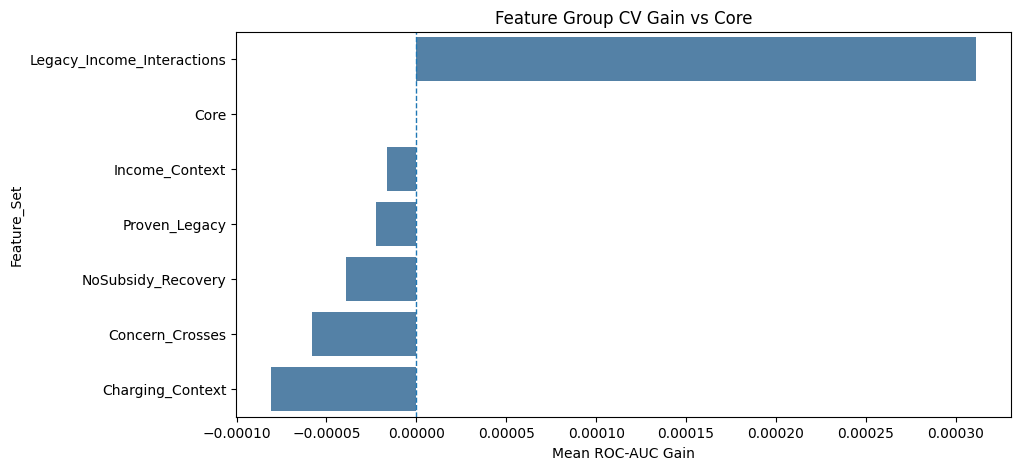

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_group_cv, x="Delta_vs_Core", y="Feature_Set", color="steelblue")
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Feature Group CV Gain vs Core")
plt.xlabel("Mean ROC-AUC Gain")
plt.show()

This is the main guardrail against feature explosion. A feature group that sounds clever but cannot improve repeated CV does not enter the advanced model.

## Select the Final Advanced Feature Set

In [18]:
accepted_groups = feature_group_cv.loc[
    feature_group_cv["Decision"].str.startswith("ACCEPT"), "Feature_Set"
].tolist()

# Safe fallback: if no group passes the strict gate, keep only the single best positive group.
if not accepted_groups:
    positive = feature_group_cv[feature_group_cv["Delta_vs_Core"] > 0]
    if not positive.empty:
        accepted_groups = [positive.iloc[0]["Feature_Set"]]

selected_extra_cols = []
for g in accepted_groups:
    selected_extra_cols.extend(feature_groups[g])
selected_extra_cols = list(dict.fromkeys(selected_extra_cols))

selected_columns = core_raw_features + selected_extra_cols
X_selected, X_selected_test = encode_for_tree(train_candidates, test_candidates, selected_columns)

print("Accepted groups:", accepted_groups)
print("Selected raw columns:", len(selected_columns))
print("Final encoded columns:", X_selected.shape[1])
print("Train/test aligned:", X_selected.columns.equals(X_selected_test.columns))

Accepted groups: ['Legacy_Income_Interactions']
Selected raw columns: 15
Final encoded columns: 22
Train/test aligned: True


In [19]:
feature_group_cv.to_csv(ANALYSIS_PATH / "advanced_feature_group_cv.csv", index=False)

selected_manifest = {
    "accepted_groups": accepted_groups,
    "selected_raw_columns": selected_columns,
    "encoded_columns": X_selected.columns.tolist()
}
with open(ANALYSIS_PATH / "advanced_feature_manifest.json", "w", encoding="utf-8") as f:
    json.dump(selected_manifest, f, indent=2)

print("Feature-selection artifacts saved.")

Feature-selection artifacts saved.


## Native Categorical CatBoost Branch

The old CatBoost saw the same one-hot numerical representation as the other boosting models. That limited ensemble diversity.

This branch keeps the selected **raw categorical crosses as categorical variables** so CatBoost can model them in its native representation.

In [20]:
X_cat = train_candidates[selected_columns].copy()
X_cat_test = test_candidates[selected_columns].copy()

cat_feature_names = X_cat.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_feature_names:
    X_cat[c] = X_cat[c].astype(str)
    X_cat_test[c] = X_cat_test[c].astype(str)

cat_feature_idx = [X_cat.columns.get_loc(c) for c in cat_feature_names]

print("CatBoost raw feature count:", X_cat.shape[1])
print("Native categorical features:", len(cat_feature_names))
print(cat_feature_names[:20])

CatBoost raw feature count: 15
Native categorical features: 3
['Gender', 'City_Type', 'Current_Car_Type']


## Advanced Hyperparameter Tuning

Tuning is controlled rather than exhaustive. A fixed stratified tuning split is used to search parameters cheaply; the final judgment still comes from full **5-fold OOF** afterward.

This avoids spending most of the project budget on Optuna while keeping the final validation much stronger than a single holdout.

In [21]:
tune_idx = np.arange(len(y))
if not FAST_MODE and len(tune_idx) > 250000:
    tune_idx, _ = train_test_split(
        tune_idx,
        train_size=250000,
        stratify=y,
        random_state=RANDOM_STATE
    )

tune_idx = np.asarray(tune_idx)
tr_tune_idx, va_tune_idx = train_test_split(
    tune_idx,
    test_size=0.20,
    stratify=y.iloc[tune_idx],
    random_state=RANDOM_STATE
)

print("Tuning train rows:", len(tr_tune_idx))
print("Tuning valid rows:", len(va_tune_idx))

Tuning train rows: 200000
Tuning valid rows: 50000


In [22]:
base_lgb_params = {
    "objective": "binary",
    "learning_rate": 0.035,
    "n_estimators": 1800 if not FAST_MODE else 250,
    "num_leaves": 31,
    "min_child_samples": 40,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.2,
    "reg_lambda": 0.8,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

if RUN_TUNING:
    def objective_lgb(trial):
        params = base_lgb_params.copy()
        params.update({
            "num_leaves": trial.suggest_int("num_leaves", 15, 80),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 120),
            "subsample": trial.suggest_float("subsample", 0.70, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 3.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        })
        model = LGBMClassifier(**params)
        model.fit(
            X_selected.iloc[tr_tune_idx], y.iloc[tr_tune_idx],
            eval_set=[(X_selected.iloc[va_tune_idx], y.iloc[va_tune_idx])],
            eval_metric="auc",
            callbacks=[early_stopping(80 if not FAST_MODE else 20, verbose=False), log_evaluation(0)]
        )
        p = model.predict_proba(X_selected.iloc[va_tune_idx])[:, 1]
        return roc_auc_score(y.iloc[va_tune_idx], p)

    study_lgb = optuna.create_study(direction="maximize")
    study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_LGB, show_progress_bar=False)
    lgb_params = base_lgb_params.copy()
    lgb_params.update(study_lgb.best_params)
    print("LightGBM tuning AUC:", round(study_lgb.best_value, 6))
    print(study_lgb.best_params)
else:
    study_lgb = None
    lgb_params = base_lgb_params.copy()
    print("LightGBM tuning skipped.")

LightGBM tuning AUC: 0.941549
{'num_leaves': 32, 'max_depth': 5, 'min_child_samples': 62, 'subsample': 0.8817235035948334, 'colsample_bytree': 0.7422521041205801, 'reg_alpha': 0.00010017150529609082, 'reg_lambda': 2.9385486048550478}


In [23]:
base_cat_params = {
    "iterations": 1800 if not FAST_MODE else 250,
    "learning_rate": 0.05,
    "depth": 7,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": -1,
}

if RUN_TUNING:
    def objective_cat(trial):
        params = base_cat_params.copy()
        params.update({
            "depth": trial.suggest_int("depth", 5, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 3.0),
        })
        model = CatBoostClassifier(**params)
        model.fit(
            X_cat.iloc[tr_tune_idx], y.iloc[tr_tune_idx],
            cat_features=cat_feature_idx,
            eval_set=(X_cat.iloc[va_tune_idx], y.iloc[va_tune_idx]),
            early_stopping_rounds=80 if not FAST_MODE else 20,
            verbose=False
        )
        p = model.predict_proba(X_cat.iloc[va_tune_idx])[:, 1]
        return roc_auc_score(y.iloc[va_tune_idx], p)

    study_cat = optuna.create_study(direction="maximize")
    study_cat.optimize(objective_cat, n_trials=N_TRIALS_CAT, show_progress_bar=False)
    cat_params = base_cat_params.copy()
    cat_params.update(study_cat.best_params)
    print("CatBoost tuning AUC:", round(study_cat.best_value, 6))
    print(study_cat.best_params)
else:
    study_cat = None
    cat_params = base_cat_params.copy()
    print("CatBoost tuning skipped.")

CatBoost tuning AUC: 0.941382
{'depth': 5, 'l2_leaf_reg': 3.6264901626422943, 'random_strength': 1.951232084155201, 'bagging_temperature': 0.35889771471518656}


In [24]:
base_xgb_params = {
    "n_estimators": 1600 if not FAST_MODE else 250,
    "learning_rate": 0.04,
    "max_depth": 7,
    "min_child_weight": 4,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.15,
    "reg_lambda": 1.0,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "early_stopping_rounds": 80 if not FAST_MODE else 20,
}

xgb_params = base_xgb_params.copy()

if RUN_TUNING and RUN_XGB_TUNING:
    def objective_xgb(trial):
        params = base_xgb_params.copy()
        params.update({
            "max_depth": trial.suggest_int("max_depth", 4, 10),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 3.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        })
        model = XGBClassifier(**params)
        model.fit(
            X_selected.iloc[tr_tune_idx], y.iloc[tr_tune_idx],
            eval_set=[(X_selected.iloc[va_tune_idx], y.iloc[va_tune_idx])],
            verbose=False
        )
        p = model.predict_proba(X_selected.iloc[va_tune_idx])[:, 1]
        return roc_auc_score(y.iloc[va_tune_idx], p)

    study_xgb = optuna.create_study(direction="maximize")
    study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_XGB, show_progress_bar=False)
    xgb_params.update(study_xgb.best_params)
    print("XGBoost tuning AUC:", round(study_xgb.best_value, 6))
    print(study_xgb.best_params)
else:
    study_xgb = None
    print("XGBoost uses a strong controlled parameter set.")

XGBoost uses a strong controlled parameter set.


## Final 5-Fold OOF Training

Now the selected representation is frozen. The next scores are the important ones: every row receives an out-of-fold prediction from models that did not train on that row.

The Kaggle test predictions are averaged across folds, which also gives us a natural CV ensemble instead of relying on one final random split.

In [25]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

model_names = ["LightGBM", "XGBoost", "NativeCatBoost"]
oof_pred = {name: np.zeros(len(y), dtype=float) for name in model_names}
test_pred = {name: np.zeros(len(test_work), dtype=float) for name in model_names}
fold_rows = []
last_models = {}

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_selected, y), 1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    lgb_model = LGBMClassifier(**lgb_params)
    lgb_model.fit(
        X_selected.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X_selected.iloc[va_idx], y.iloc[va_idx])],
        eval_metric="auc",
        callbacks=[early_stopping(100 if not FAST_MODE else 20, verbose=False), log_evaluation(0)]
    )
    p_lgb = lgb_model.predict_proba(X_selected.iloc[va_idx])[:, 1]
    oof_pred["LightGBM"][va_idx] = p_lgb
    test_pred["LightGBM"] += lgb_model.predict_proba(X_selected_test)[:, 1] / N_SPLITS

    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(
        X_selected.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X_selected.iloc[va_idx], y.iloc[va_idx])],
        verbose=False
    )
    p_xgb = xgb_model.predict_proba(X_selected.iloc[va_idx])[:, 1]
    oof_pred["XGBoost"][va_idx] = p_xgb
    test_pred["XGBoost"] += xgb_model.predict_proba(X_selected_test)[:, 1] / N_SPLITS

    cat_model = CatBoostClassifier(**cat_params)
    cat_model.fit(
        X_cat.iloc[tr_idx], y.iloc[tr_idx],
        cat_features=cat_feature_idx,
        eval_set=(X_cat.iloc[va_idx], y.iloc[va_idx]),
        early_stopping_rounds=100 if not FAST_MODE else 20,
        verbose=False
    )
    p_cat = cat_model.predict_proba(X_cat.iloc[va_idx])[:, 1]
    oof_pred["NativeCatBoost"][va_idx] = p_cat
    test_pred["NativeCatBoost"] += cat_model.predict_proba(X_cat_test)[:, 1] / N_SPLITS

    scores = {
        "LightGBM": roc_auc_score(y.iloc[va_idx], p_lgb),
        "XGBoost": roc_auc_score(y.iloc[va_idx], p_xgb),
        "NativeCatBoost": roc_auc_score(y.iloc[va_idx], p_cat),
    }
    for name, auc in scores.items():
        fold_rows.append({"Fold": fold, "Model": name, "ROC_AUC": auc})
    print({k: round(v, 6) for k, v in scores.items()})

    last_models = {
        "LightGBM": lgb_model,
        "XGBoost": xgb_model,
        "NativeCatBoost": cat_model,
    }

fold_results = pd.DataFrame(fold_rows)


===== Fold 1/5 =====
{'LightGBM': 0.940939, 'XGBoost': 0.940847, 'NativeCatBoost': 0.940935}

===== Fold 2/5 =====
{'LightGBM': 0.942058, 'XGBoost': 0.94167, 'NativeCatBoost': 0.941831}

===== Fold 3/5 =====
{'LightGBM': 0.94346, 'XGBoost': 0.942975, 'NativeCatBoost': 0.943149}

===== Fold 4/5 =====
{'LightGBM': 0.942816, 'XGBoost': 0.942477, 'NativeCatBoost': 0.942653}

===== Fold 5/5 =====
{'LightGBM': 0.942246, 'XGBoost': 0.941991, 'NativeCatBoost': 0.942104}


In [26]:
oof_single_auc = {name: roc_auc_score(y, pred) for name, pred in oof_pred.items()}
single_results = pd.DataFrame({
    "Model": list(oof_single_auc.keys()),
    "OOF_ROC_AUC": list(oof_single_auc.values())
}).sort_values("OOF_ROC_AUC", ascending=False)

single_results

,Model,OOF_ROC_AUC
0,LightGBM,0.942297
2,NativeCatBoost,0.942129
1,XGBoost,0.941982


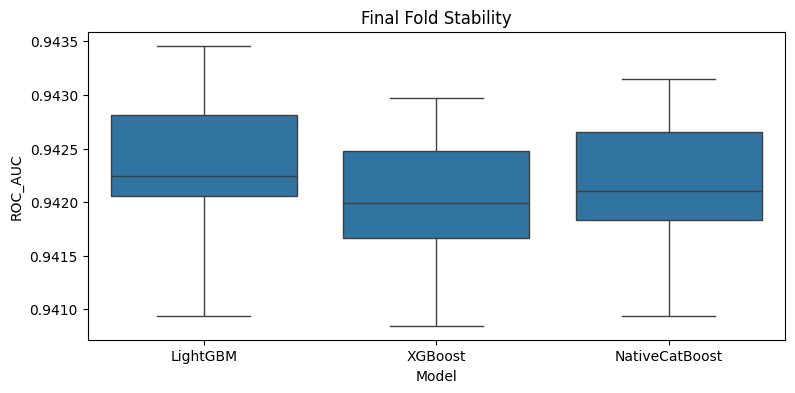

In [27]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=fold_results, x="Model", y="ROC_AUC")
plt.title("Final Fold Stability")
plt.show()

At this point, native CatBoost earns its place only if it either improves AUC directly or produces genuinely different rankings that help the ensemble.

## OOF Probability and Rank Blending

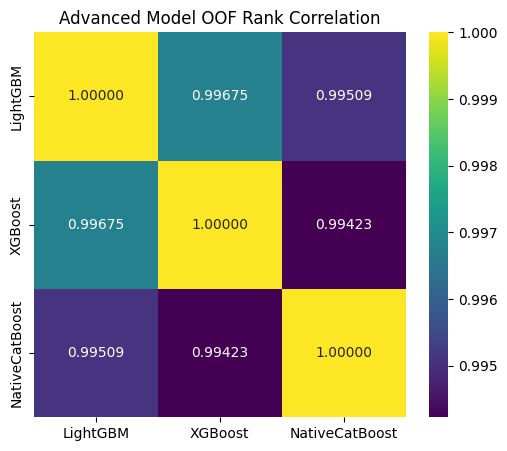

,LightGBM,XGBoost,NativeCatBoost
LightGBM,1.000000,0.996749,0.995091
XGBoost,0.996749,1.000000,0.994228
NativeCatBoost,0.995091,0.994228,1.000000


In [28]:
pred_corr = pd.DataFrame(oof_pred).corr(method="spearman")
plt.figure(figsize=(6, 5))
sns.heatmap(pred_corr, annot=True, fmt=".5f", cmap="viridis")
plt.title("Advanced Model OOF Rank Correlation")
plt.show()
pred_corr

In [29]:
def search_three_model_blend(pred_a, pred_b, pred_c, y_true, step=0.05):
    best_auc = -np.inf
    best_weights = None
    best_pred = None
    weights = np.arange(0.0, 1.0001, step)
    for wa in weights:
        for wb in weights:
            wc = 1.0 - wa - wb
            if wc < -1e-12:
                continue
            wc = max(0.0, wc)
            p = wa * pred_a + wb * pred_b + wc * pred_c
            auc = roc_auc_score(y_true, p)
            if auc > best_auc:
                best_auc, best_weights, best_pred = auc, (wa, wb, wc), p
    return best_auc, best_weights, best_pred

lgb_oof = oof_pred["LightGBM"]
xgb_oof = oof_pred["XGBoost"]
cat_oof = oof_pred["NativeCatBoost"]

prob_auc, prob_weights, prob_oof = search_three_model_blend(lgb_oof, xgb_oof, cat_oof, y, step=0.05)

rank_lgb = rankdata(lgb_oof, method="average") / len(y)
rank_xgb = rankdata(xgb_oof, method="average") / len(y)
rank_cat = rankdata(cat_oof, method="average") / len(y)
rank_auc, rank_weights, rank_oof = search_three_model_blend(rank_lgb, rank_xgb, rank_cat, y, step=0.05)

simple_rank_oof = (rank_lgb + rank_xgb + rank_cat) / 3.0
simple_rank_auc = roc_auc_score(y, simple_rank_oof)

print("Best single:", max(oof_single_auc, key=oof_single_auc.get), round(max(oof_single_auc.values()), 6))
print("Probability blend:", round(prob_auc, 6), "weights:", tuple(round(x, 2) for x in prob_weights))
print("Simple rank average:", round(simple_rank_auc, 6))
print("Weighted rank blend:", round(rank_auc, 6), "weights:", tuple(round(x, 2) for x in rank_weights))

Best single: LightGBM 0.942297
Probability blend: 0.942399 weights: (np.float64(0.55), np.float64(0.1), np.float64(0.35))
Simple rank average: 0.94237
Weighted rank blend: 0.942404 weights: (np.float64(0.55), np.float64(0.1), np.float64(0.35))


In [30]:
ensemble_results = pd.DataFrame([
    *[{"Candidate": k, "OOF_ROC_AUC": v} for k, v in oof_single_auc.items()],
    {"Candidate": "Probability_Blend", "OOF_ROC_AUC": prob_auc},
    {"Candidate": "Simple_Rank_Average", "OOF_ROC_AUC": simple_rank_auc},
    {"Candidate": "Weighted_Rank_Blend", "OOF_ROC_AUC": rank_auc},
]).sort_values("OOF_ROC_AUC", ascending=False).reset_index(drop=True)
ensemble_results

,Candidate,OOF_ROC_AUC
0,Weighted_Rank_Blend,0.942404
1,Probability_Blend,0.942399
2,Simple_Rank_Average,0.942370
3,LightGBM,0.942297
4,NativeCatBoost,0.942129
5,XGBoost,0.941982


## Compare Against Notebook-04 Reference

In [31]:
advanced_best_name = ensemble_results.iloc[0]["Candidate"]
advanced_best_auc = float(ensemble_results.iloc[0]["OOF_ROC_AUC"])

if advanced_best_name == "Probability_Blend":
    advanced_best_oof = prob_oof
elif advanced_best_name == "Weighted_Rank_Blend":
    advanced_best_oof = rank_oof
elif advanced_best_name == "Simple_Rank_Average":
    advanced_best_oof = simple_rank_oof
else:
    advanced_best_oof = oof_pred[advanced_best_name]

print("Advanced best:", advanced_best_name, round(advanced_best_auc, 6))
if pd.notna(reference_auc):
    print("Notebook-04 reference:", round(float(reference_auc), 6))
    print("OOF gain:", round(advanced_best_auc - float(reference_auc), 6))
else:
    print("Notebook-04 full OOF reference is unavailable in this environment.")

Advanced best: Weighted_Rank_Blend 0.942404
Notebook-04 reference: 0.942359
OOF gain: 4.5e-05


## Weak-Group Validation Gate

In [32]:
eval_frame = train_work[[
    "id", "Environmental_Concern_Level", "Subsidy_Available",
    "Home_Charging_Possible", "Range_Anxiety_Level", "City_Type"
]].copy()
eval_frame["target"] = y.to_numpy()
eval_frame["advanced_prob"] = advanced_best_oof

old_for_merge = pd.DataFrame()
if not old_oof.empty and {"id", "OOF_Blend"}.issubset(old_oof.columns):
    old_for_merge = old_oof[["id", "OOF_Blend"]].rename(columns={"OOF_Blend": "old_prob"})
    eval_frame = eval_frame.merge(old_for_merge, on="id", how="left")

subgroup_rows = []

def add_group_auc(frame, feature, value, label):
    part = frame[frame[feature] == value]
    if len(part) < 50 or part["target"].nunique() < 2:
        return
    row = {
        "Segment": label,
        "Rows": len(part),
        "Positive_Rate": part["target"].mean(),
        "Advanced_AUC": roc_auc_score(part["target"], part["advanced_prob"]),
    }
    if "old_prob" in part.columns and part["old_prob"].notna().sum() >= 50:
        old_part = part.dropna(subset=["old_prob"])
        if old_part["target"].nunique() == 2:
            row["Old_AUC"] = roc_auc_score(old_part["target"], old_part["old_prob"])
            row["Delta"] = row["Advanced_AUC"] - row["Old_AUC"]
    subgroup_rows.append(row)

for concern_value in sorted(eval_frame["Environmental_Concern_Level"].unique()):
    add_group_auc(eval_frame, "Environmental_Concern_Level", concern_value, f"Concern={concern_value:g}")

for subsidy_value in ["No", "Yes"]:
    add_group_auc(eval_frame, "Subsidy_Available", subsidy_value, f"Subsidy={subsidy_value}")

subgroup_comparison = pd.DataFrame(subgroup_rows)
subgroup_comparison

,Segment,Rows,Positive_Rate,Advanced_AUC,Old_AUC,Delta
0,Concern=1,147476,0.005655,0.826582,0.825784,0.000798
1,Concern=2,135133,0.021379,0.838879,0.838779,0.000100
2,Concern=3,127351,0.110922,0.852359,0.852373,-0.000014
3,Concern=4,130469,0.248848,0.867029,0.866956,0.000073
4,Concern=5,128236,0.518287,0.874235,0.874228,0.000007
5,Subsidy=No,248756,0.005757,0.875241,0.873875,0.001366
6,Subsidy=Yes,419909,0.274695,0.905086,0.905042,0.000044


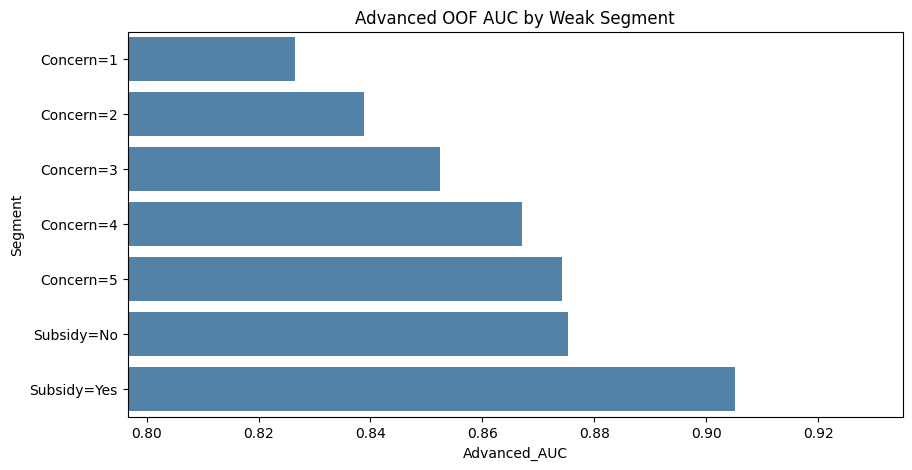

In [33]:
if not subgroup_comparison.empty:
    plt.figure(figsize=(10, 5))
    plot_cols = ["Segment", "Advanced_AUC"]
    temp = subgroup_comparison[plot_cols].copy()
    sns.barplot(data=temp, x="Advanced_AUC", y="Segment", color="steelblue")
    plt.title("Advanced OOF AUC by Weak Segment")
    plt.xlim(max(0.5, temp["Advanced_AUC"].min() - 0.03), min(1.0, temp["Advanced_AUC"].max() + 0.03))
    plt.show()

This gate matters because a tiny overall gain can hide a large improvement in the exact segments that previously failed. We care about both.

## Ranking Error Recheck

In [34]:
def ranking_error_summary(y_true, prob, label):
    pct = rankdata(prob, method="average") / len(prob)
    y_arr = np.asarray(y_true)
    hard_pos = (y_arr == 1) & (pct <= 0.20)
    hard_neg = (y_arr == 0) & (pct >= 0.80)
    return {
        "System": label,
        "Positive_in_bottom_20pct": int(hard_pos.sum()),
        "Negative_in_top_20pct": int(hard_neg.sum()),
        "Hard_Total": int(hard_pos.sum() + hard_neg.sum())
    }

rank_error_rows = [ranking_error_summary(y, advanced_best_oof, "Advanced")]

if "old_prob" in eval_frame.columns:
    aligned = eval_frame.dropna(subset=["old_prob"])
    if len(aligned) > 0:
        rank_error_rows.append(ranking_error_summary(aligned["target"], aligned["old_prob"], "Notebook04"))

rank_error_df = pd.DataFrame(rank_error_rows)
rank_error_df

,System,Positive_in_bottom_20pct,Negative_in_top_20pct,Hard_Total
0,Advanced,43,43853,43896
1,Notebook04,43,43868,43911


In [35]:
advanced_pct = rankdata(advanced_best_oof, method="average") / len(advanced_best_oof)
hard_error_mask = ((y.to_numpy() == 1) & (advanced_pct <= 0.20)) | ((y.to_numpy() == 0) & (advanced_pct >= 0.80))

hard_error_profile = train_work.loc[hard_error_mask, [
    "Annual_Income_USD", "Environmental_Concern_Level", "Daily_Commute_km",
    "Charging_Stations_Near_Home", "Charging_Stations_Near_Work"
]].describe().T
hard_error_profile

,count,mean,std,min,25%,50%,75%,max
Annual_Income_USD,"43,896.000000","97,340.072171","23,116.644929","30,000.000000","81,951.000000","93,957.000000","112,562.000000","169,626.000000"
Environmental_Concern_Level,"43,896.000000",4.394478,0.623115,1.000000,4.000000,4.000000,5.000000,5.000000
Daily_Commute_km,"43,896.000000",30.245227,18.187469,5.000000,12.800000,31.800000,45.500000,82.800000
Charging_Stations_Near_Home,"43,896.000000",4.775879,3.938261,0.000000,2.000000,4.000000,7.000000,14.000000
Charging_Stations_Near_Work,"43,896.000000",6.985261,5.173767,0.000000,3.000000,6.000000,9.000000,19.000000


## Explainability Sanity Check

Notebook 04 had a SHAP availability problem. Here we use LightGBM's native `pred_contrib=True` as a reliable fallback, so the explainability check cannot silently disappear.

In [36]:
explain_model = last_models["LightGBM"]
explain_n = min(5000 if not FAST_MODE else 1000, len(X_selected))
explain_sample = X_selected.sample(explain_n, random_state=RANDOM_STATE)

try:
    contrib = explain_model.booster_.predict(explain_sample, pred_contrib=True)
    contrib_abs = np.abs(contrib[:, :-1]).mean(axis=0)
    contribution_df = pd.DataFrame({
        "Feature": X_selected.columns,
        "MeanAbs_Contribution": contrib_abs
    }).sort_values("MeanAbs_Contribution", ascending=False)
except Exception as exc:
    print("Native contribution analysis failed:", exc)
    contribution_df = pd.DataFrame(columns=["Feature", "MeanAbs_Contribution"])

contribution_df.head(20)

,Feature,MeanAbs_Contribution
8,Subsidy_Available,1.342548
10,Income_x_Concern,1.028753
6,Environmental_Concern_Level,0.860597
11,Subsidy_x_Income,0.610038
9,Range_Anxiety_Level,0.244812
1,Annual_Income_USD,0.128620
0,Age,0.119931
2,Daily_Commute_km,0.110268
7,Home_Charging_Possible,0.082351
4,Charging_Stations_Near_Home,0.066092


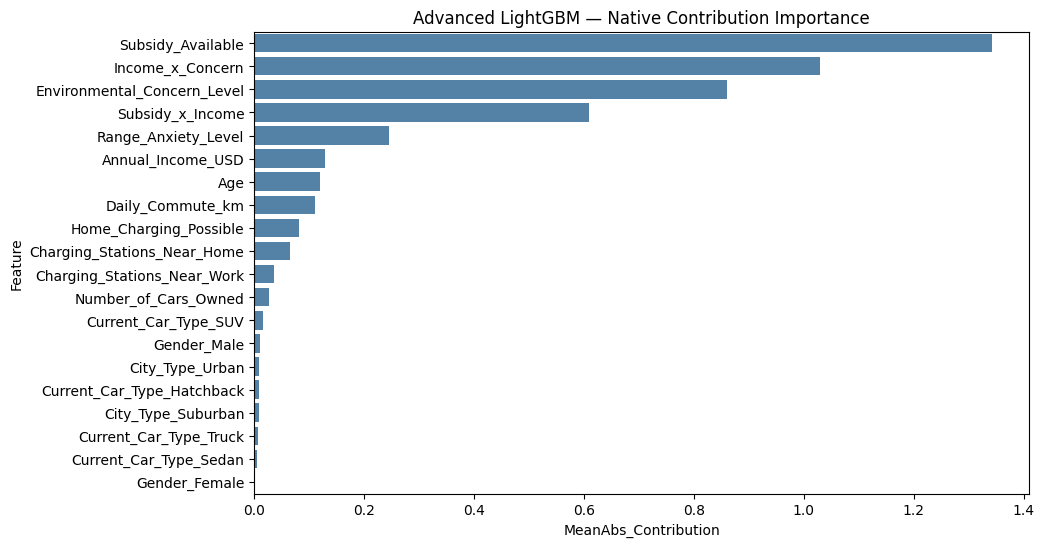

In [37]:
if not contribution_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=contribution_df.head(20), x="MeanAbs_Contribution", y="Feature", color="steelblue")
    plt.title("Advanced LightGBM — Native Contribution Importance")
    plt.show()

## Build Kaggle Test Predictions

In [38]:
best_single_name = max(oof_single_auc, key=oof_single_auc.get)
single_test_prob = test_pred[best_single_name]

wa, wb, wc = prob_weights
prob_test = (
    wa * test_pred["LightGBM"] +
    wb * test_pred["XGBoost"] +
    wc * test_pred["NativeCatBoost"]
)

rank_test_lgb = rankdata(test_pred["LightGBM"], method="average") / len(test_work)
rank_test_xgb = rankdata(test_pred["XGBoost"], method="average") / len(test_work)
rank_test_cat = rankdata(test_pred["NativeCatBoost"], method="average") / len(test_work)

rwa, rwb, rwc = rank_weights
rank_test = rwa * rank_test_lgb + rwb * rank_test_xgb + rwc * rank_test_cat

print("Best single model:", best_single_name)
print("Single range:", float(single_test_prob.min()), float(single_test_prob.max()))
print("Probability blend range:", float(prob_test.min()), float(prob_test.max()))
print("Rank blend range:", float(rank_test.min()), float(rank_test.max()))

Best single model: LightGBM
Single range: 7.114324324707984e-06 0.9764492880367457
Probability blend range: 8.803871039936241e-06 0.973110246905471
Rank blend range: 1.6051868472385552e-05 0.9999951146487258


## Kaggle Submission Files

In [39]:
submission_single = pd.DataFrame({
    "id": test_ids,
    "Will_Buy_EV": single_test_prob
})
submission_prob = pd.DataFrame({
    "id": test_ids,
    "Will_Buy_EV": prob_test
})
submission_rank = pd.DataFrame({
    "id": test_ids,
    "Will_Buy_EV": rank_test
})

submission_single.to_csv(SUBMISSION_PATH / "submission_advanced_single.csv", index=False)
submission_prob.to_csv(SUBMISSION_PATH / "submission_advanced_probability_blend.csv", index=False)
submission_rank.to_csv(SUBMISSION_PATH / "submission_advanced_rank_blend.csv", index=False)

submission_single.head()

,id,Will_Buy_EV
0,668665,0.011135
1,668666,0.019356
2,668667,0.005453
3,668668,0.003116
4,668669,0.020858


In [40]:
for name, sub in {
    "single": submission_single,
    "probability_blend": submission_prob,
    "rank_blend": submission_rank,
}.items():
    print(
        name,
        "shape=", sub.shape,
        "duplicates=", sub["id"].duplicated().sum(),
        "missing=", sub["Will_Buy_EV"].isna().sum(),
        "inside_0_1=", sub["Will_Buy_EV"].between(0, 1).all()
    )

single shape= (286571, 2) duplicates= 0 missing= 0 inside_0_1= True
probability_blend shape= (286571, 2) duplicates= 0 missing= 0 inside_0_1= True
rank_blend shape= (286571, 2) duplicates= 0 missing= 0 inside_0_1= True


For ROC-AUC, the rank-blend submission is valid even though the values are rank-normalized rather than calibrated purchase probabilities. Kaggle only cares about the ordering for this metric.

## Save OOF Diagnostics and Model Artifacts

In [41]:
advanced_oof = pd.DataFrame({
    "id": train_ids,
    "target": y,
    "LightGBM": oof_pred["LightGBM"],
    "XGBoost": oof_pred["XGBoost"],
    "NativeCatBoost": oof_pred["NativeCatBoost"],
    "Probability_Blend": prob_oof,
    "Weighted_Rank_Blend": rank_oof,
    "Advanced_Best": advanced_best_oof,
})
advanced_oof.to_csv(ANALYSIS_PATH / "advanced_model_oof.csv", index=False)

subgroup_comparison.to_csv(ANALYSIS_PATH / "advanced_subgroup_comparison.csv", index=False)
rank_error_df.to_csv(ANALYSIS_PATH / "advanced_rank_error_comparison.csv", index=False)
contribution_df.to_csv(ANALYSIS_PATH / "advanced_feature_contributions.csv", index=False)

joblib.dump(last_models["LightGBM"], MODELS_PATH / "advanced_lightgbm_last_fold.pkl")
joblib.dump(last_models["XGBoost"], MODELS_PATH / "advanced_xgboost_last_fold.pkl")
last_models["NativeCatBoost"].save_model(str(MODELS_PATH / "advanced_catboost_last_fold.cbm"))

advanced_metadata = {
    "random_state": RANDOM_STATE,
    "n_splits": N_SPLITS,
    "reference_auc": None if pd.isna(reference_auc) else float(reference_auc),
    "accepted_feature_groups": accepted_groups,
    "selected_columns": selected_columns,
    "encoded_feature_count": int(X_selected.shape[1]),
    "oof_single_auc": {k: float(v) for k, v in oof_single_auc.items()},
    "probability_blend_auc": float(prob_auc),
    "probability_blend_weights": [float(x) for x in prob_weights],
    "rank_blend_auc": float(rank_auc),
    "rank_blend_weights": [float(x) for x in rank_weights],
    "advanced_best_name": advanced_best_name,
    "advanced_best_auc": float(advanced_best_auc),
}
with open(MODELS_PATH / "advanced_training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(advanced_metadata, f, indent=2)

print("Advanced artifacts saved.")

Advanced artifacts saved.


## Final Evidence Summary

In [42]:
summary_rows = [
    ["Notebook-04 reference", reference_auc],
    ["Advanced LightGBM", oof_single_auc["LightGBM"]],
    ["Advanced XGBoost", oof_single_auc["XGBoost"]],
    ["Native CatBoost", oof_single_auc["NativeCatBoost"]],
    ["Probability blend", prob_auc],
    ["Weighted rank blend", rank_auc],
]
final_summary = pd.DataFrame(summary_rows, columns=["System", "OOF_ROC_AUC"])
final_summary["Gain_vs_Reference"] = final_summary["OOF_ROC_AUC"] - reference_auc if pd.notna(reference_auc) else np.nan
final_summary.sort_values("OOF_ROC_AUC", ascending=False)

,System,OOF_ROC_AUC,Gain_vs_Reference
5,Weighted rank blend,0.942404,0.000045
4,Probability blend,0.942399,0.000040
0,Notebook-04 reference,0.942359,0.000000
1,Advanced LightGBM,0.942297,-0.000062
3,Native CatBoost,0.942129,-0.000230
2,Advanced XGBoost,0.941982,-0.000377


In [43]:
print("Selected feature groups:", accepted_groups)
print("Advanced winner:", advanced_best_name)
print("Advanced OOF AUC:", round(advanced_best_auc, 6))
if pd.notna(reference_auc):
    print("Gain vs Notebook 04:", round(advanced_best_auc - float(reference_auc), 6))
print("Mean advanced model rank correlation:", round(float(pred_corr.where(~np.eye(len(pred_corr), dtype=bool)).stack().mean()), 6))

Selected feature groups: ['Legacy_Income_Interactions']
Advanced winner: Weighted_Rank_Blend
Advanced OOF AUC: 0.942404
Gain vs Notebook 04: 4.5e-05
Mean advanced model rank correlation: 0.995356


## Notebook 05 Summary

This notebook deliberately treated feature engineering as a **model-selection problem**, not a creativity contest.

What changed from the previous system:

- redundant legacy features were no longer assumed useful;
- concern-level weaknesses were targeted with categorical context features;
- no-subsidy buyers received their own recovery features;
- every feature family was screened with repeated CV before entering the final matrix;
- CatBoost received native categorical crosses instead of the same one-hot matrix as every other model;
- blend weights were learned from OOF predictions;
- both probability blending and ROC-AUC-friendly rank blending were tested;
- the old weak customer segments were checked again before submission;
- LightGBM native contributions replaced the SHAP section that could silently fail in Notebook 04.

The three submission files now let the Kaggle leaderboard answer the last question: **best single model, probability ensemble, or rank ensemble?**